# Eigen-Interactions Filtering

Apply the eigen-interactions package to sequences from the joint library (~57k).

### Steps

1. **Load sequences** from joint library

2. **Compute DeepLIFT/SHAP attributions** $A(s, k)$ for sequence $s$ across $k$ cell lines

3. **Compute Covariance matrix** $\mathbf{C}$ where:

$\displaystyle C_{ij} = \text{Cov}\!\big(A(s, k_i),\; A(s, k_j)\big) = \frac{1}{L}\sum_{\ell=1}^{L} A_\ell(s, k_i)\, A_\ell(s, k_j) \;-\; \bar{A}(s, k_i)\,\bar{A}(s, k_j)$

   - **Diagonal:** $C_{ii} = \text{Var}\!\big(A(s, k_i)\big)$
   - **Off-diagonal:** $C_{ij} = \text{Cov}\!\big(A(s, k_i),\; A(s, k_j)\big),\quad i \neq j$

4. **Find eigen-interactions** by diagonalizing $\mathbf{C}$:

$\displaystyle \mathbf{C} = \mathbf{V}\,\boldsymbol{\Lambda}\,\mathbf{V}^\top \qquad\Longrightarrow\qquad \text{EI}_m(s) = \sum_{k} V_{km}\, A(s, k)$

   so that in the new basis $(\text{EI}_1, \text{EI}_2, \ldots)$ the off-diagonals $\approx 0$.

5. **Plot** all $\text{EI}_1(s)$ projected onto 3D coordinates $(\text{HepG2},\; \text{K562},\; \text{WTC11})$.

In [1]:
import os, sys, importlib
import numpy as np
import pandas as pd

os.environ['CUDA_VISIBLE_DEVICES'] = '0'

REPO = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
EIGEN_DIR = os.path.join(REPO, 'eigen-interactions')
sys.path.insert(0, EIGEN_DIR)

import eigen_steering; importlib.reload(eigen_steering)
from eigen_steering import EigenMap, PROMOTER_SEQ, RAND_BARCODE

# Override paths to point at our local models instead of the training repo
eigen_steering.WEIGHTS_PATH = '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/weights/model_fold_0.safetensors'
eigen_steering.RESULTS_DIR = os.path.join(REPO, 'models')

# Our model dirs have best_stage2.pt directly (no checkpoints/ subdir),
# so patch _load_model to look in the right place
_orig_load = EigenMap._load_model
def _patched_load(self, ct, squeeze=False):
    model_name = self.model_names[ct]
    ckpt_dir = os.path.join(eigen_steering.RESULTS_DIR, model_name)
    # Check both layouts: direct and checkpoints/
    direct = os.path.join(ckpt_dir, 'best_stage2.pt')
    nested = os.path.join(ckpt_dir, 'checkpoints', 'best_stage2.pt')
    if os.path.exists(direct) and not os.path.exists(nested):
        os.makedirs(os.path.join(ckpt_dir, 'checkpoints'), exist_ok=True)
        os.symlink(direct, nested)
    return _orig_load(self, ct, squeeze=squeeze)
EigenMap._load_model = _patched_load

DATA_CSV = os.path.join(REPO, 'data', 'joint_library_combined.csv')
print(f'Eigen-interactions loaded from {EIGEN_DIR}')

AlphaGenome patches applied (all functional activations -> nn.Module).
Eigen-interactions loaded from /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/eigen-interactions


In [2]:
# Load joint library
df = pd.read_csv(DATA_CSV)
df = df.dropna(subset=['sequence', 'K562_log2FC', 'HepG2_log2FC', 'WTC11_log2FC']).reset_index(drop=True)
df = df[0:10]
print(f'{len(df)} sequences with K562 + HepG2 + WTC11 data')

# Best models per cell line by Pearson R on joint library (validate_models.ipynb)
# K562:  do075 → r=0.8915 | do06 → r=0.8837 | do03 → r=0.8683
# HepG2: do03  → r=0.8750 | do075 → r=0.8703 | do06 → r=0.8665
# WTC11: do075 → r=0.8457 | do06 → r=0.8371 | do03 → r=0.8262
MODEL_NAMES = {
    'K562':  'K562_v6_do075',
    'HepG2': 'HepG2_v6_do03',
    'WTC11': 'WTC11_v6_do075',
}

10 sequences with K562 + HepG2 + WTC11 data


In [3]:
# Load precomputed DeepLIFT/SHAP attributions
# (computed via: bash submit_attributions.sh && bash submit_attributions.sh merge)
ATTR_PATH = os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz')

em = EigenMap(model_names=MODEL_NAMES, device='cuda')
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in MODEL_NAMES})
em.load_attributions(ATTR_PATH)

print(f'\nAttribution shapes:')
for ct in MODEL_NAMES:
    print(f'  {ct}: attr {em.attr[ct].shape}  attr_hyp {em.attr_hyp[ct].shape}  importance {em.importance[ct].shape}')

EigenMap: ['K562', 'HepG2', 'WTC11'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03', 'WTC11': 'WTC11_v6_do075'}
Loaded 10 sequences, X shape: torch.Size([10, 4, 281])


FileNotFoundError: [Errno 2] No such file or directory: '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/data/deeplift_attributions.npz'

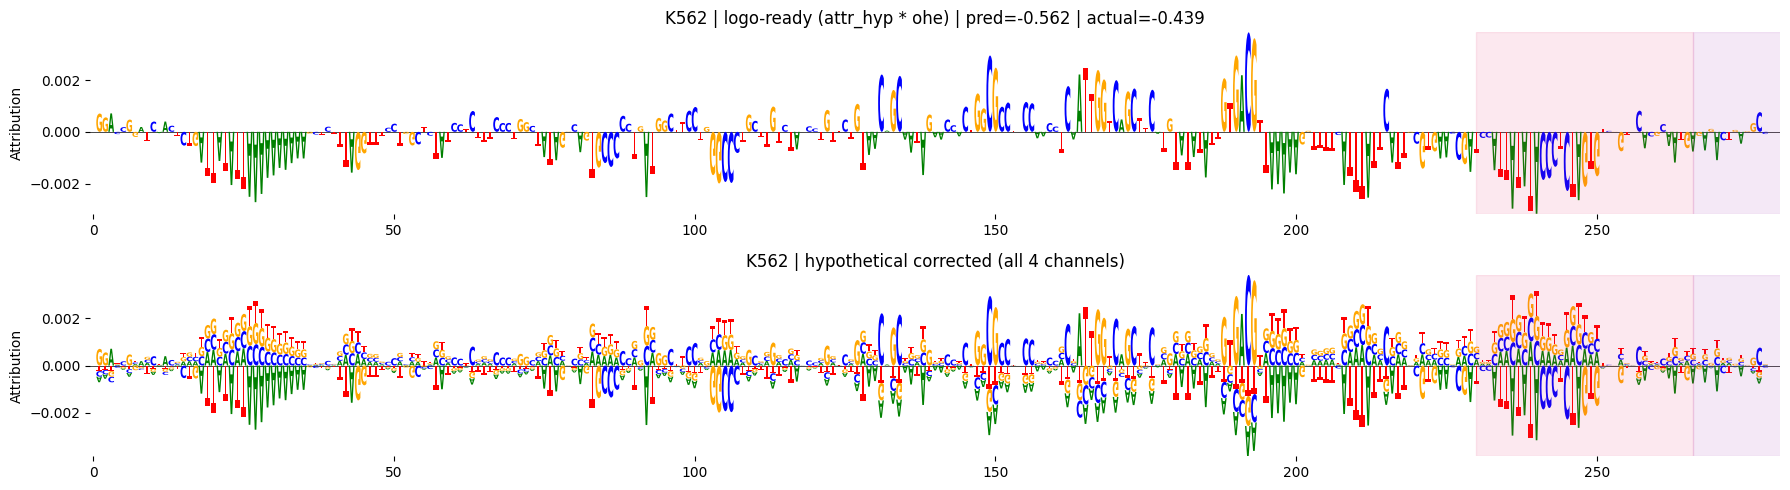

In [12]:
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.join(EIGEN_DIR, 'tangermeme'))
from tangermeme.plot import plot_logo
from eigen_steering import PROMOTER_START, BARCODE_START, TOTAL_LEN, ENHANCER_LEN, sequence_to_onehot
import torch

# Load test shard (1 seq, K562 only)
test_shard = os.path.join(REPO, 'genomic_targets', 'data', 'attr_shards', 'test', 'K562_shard_0000.npz')
d = np.load(test_shard)
attr_hyp = d['attr']     # (1, 4, 281) — hypothetical corrected
pred = d['predictions']   # (1,)

# Get the sequence to make ohe
seq = df['sequence'].iloc[0]
construct = seq + PROMOTER_SEQ + RAND_BARCODE
ohe = sequence_to_onehot(construct).astype(np.float32).T  # (4, 281)

# Logo-ready = hypothetical * ohe
attr_logo = attr_hyp[0] * ohe  # (4, 281)

fig, axes = plt.subplots(2, 1, figsize=(18, 5))

# Top: logo-ready (what you'd normally plot)
plot_logo(attr_logo, ax=axes[0])
axes[0].axvspan(ENHANCER_LEN, BARCODE_START, alpha=0.10, color='#E91E63')
axes[0].axvspan(BARCODE_START, TOTAL_LEN, alpha=0.10, color='#9C27B0')
axes[0].set_title(f'K562 | logo-ready (attr_hyp * ohe) | pred={pred[0]:.3f} | actual={df["K562_log2FC"].iloc[0]:.3f}')
axes[0].set_ylabel('Attribution')

# Bottom: hypothetical (all 4 channels, no ohe mask)
plot_logo(attr_hyp[0], ax=axes[1])
axes[1].axvspan(ENHANCER_LEN, BARCODE_START, alpha=0.10, color='#E91E63')
axes[1].axvspan(BARCODE_START, TOTAL_LEN, alpha=0.10, color='#9C27B0')
axes[1].set_title(f'K562 | hypothetical corrected (all 4 channels)')
axes[1].set_ylabel('Attribution')
#axes[1].set_xlabel('Position (230bp enhancer | 36bp promoter | 15bp barcode)')

plt.tight_layout()
plt.show()